# Formation Clustering Analysis
Runs feature extraction and k-means on `out/tournament_high_logs/`, then visualizes the clusters.

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sys
warnings.filterwarnings('ignore')

# Paths — adjust if running from a different cwd
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
LOG_DIR   = os.path.join(NOTEBOOK_DIR, 'out', 'tournament_high_logs')
OUT_DIR   = os.path.join(NOTEBOOK_DIR, 'out', 'formation_clusters')
os.makedirs(OUT_DIR, exist_ok=True)

SUBSAMPLE = 5   # read every Nth row (~0.25s coverage)
K         = 30  # number of clusters
SEED      = 42

# Field geometry
BLUE_GOAL_Y   = -5120.0
ORANGE_GOAL_Y =  5120.0

csv_files = sorted(glob.glob(os.path.join(LOG_DIR, '*.csv')))
print(f'Found {len(csv_files)} tournament log files.')

Found 31 tournament log files.


## 1. Load & Inspect Raw Data

In [2]:
# Load all files into a single dataframe (full resolution for inspection)
dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    df['source_file'] = os.path.basename(f)
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)
print(f'Total rows: {len(raw):,}  |  Columns: {len(raw.columns)}')
print(f'Unique match_ids: {raw.match_id.nunique()}  |  Ticks per match (approx): {raw.groupby("match_id").size().mean():.0f}')
raw[['match_id','tick','time_s','blue_score','orange_score','ball_px','ball_py','ball_pz','ball_vx','ball_vy','ball_vz']].describe()

Total rows: 139,572  |  Columns: 165
Unique match_ids: 31  |  Ticks per match (approx): 4502


,match_id,tick,time_s,blue_score,orange_score,ball_px,ball_py,ball_pz,ball_vx,ball_vy,ball_vz
count,139572.000000,139572.000000,139572.000000,139572.000000,139572.000000,139572.000000,139572.000000,139572.000000,139572.000000,139572.000000,139572.000000
mean,997.678023,18004.001834,150.033349,0.074514,0.086364,87.518587,22.335226,95.556913,0.206176,-0.822402,0.019975
std,22.213591,10396.772872,86.639774,0.320794,0.280902,1215.067178,1546.594782,29.629117,119.091087,135.611632,38.087485
min,961.000000,0.000000,0.000000,0.000000,0.000000,-4002.962158,-5271.049316,88.319595,-1643.063965,-1740.686035,-1158.270386
25%,977.000000,9000.000000,75.000000,0.000000,0.000000,0.000000,0.000000,93.139847,0.000000,0.000000,0.000000
50%,997.000000,18000.000000,150.000000,0.000000,0.000000,0.000000,0.000000,93.150002,0.000000,0.000000,0.000000
75%,1017.000000,27008.000000,225.066667,0.000000,0.000000,0.000000,0.000000,93.150002,0.000000,0.000000,0.000000
max,1033.000000,36000.000000,300.000000,2.000000,1.000000,4002.405518,5290.944336,1167.488281,1497.216309,1970.764771,1037.703979


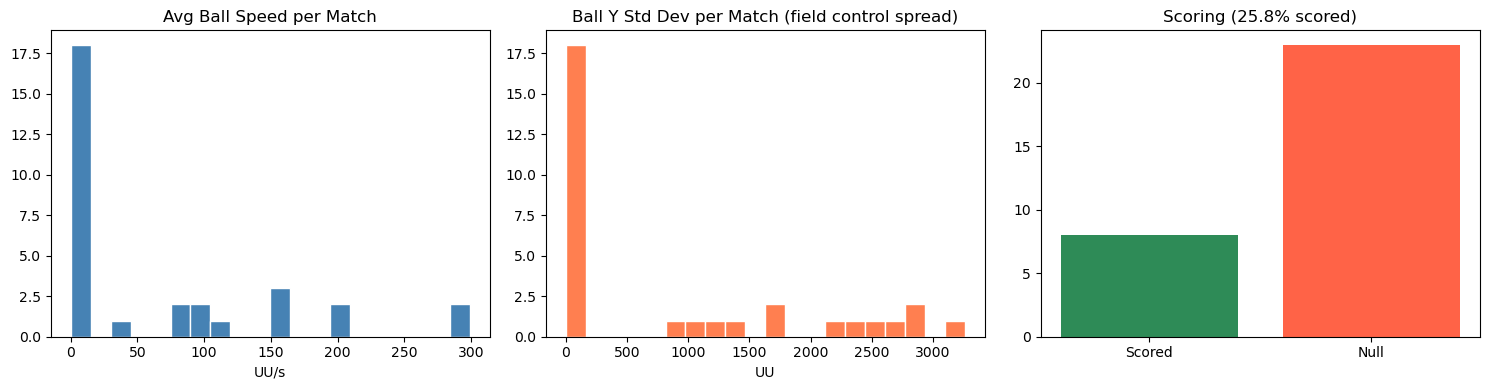

 match_id  ball_speed_mean  ball_py_std  blue_score_final  orange_score_final
      961         0.000000     0.000000                 0                   0
      962         0.000000     0.000000                 0                   0
      966         0.000000     0.000000                 0                   0
      967         0.000000     0.000000                 0                   0
      971       204.790133  1778.627699                 0                   1
      972       150.292701   978.079923                 0                   1
      976        39.235022  1101.314450                 0                   0
      977         0.000000     0.000000                 0                   0
      981       113.102748  2267.528551                 0                   0
      982        78.792138  2317.391520                 0                   0
      986         0.000000     0.000000                 0                   0
      987         0.000000     0.000000                 0       

In [3]:
# Ball activity overview per match
def ball_speed(df):
    return np.sqrt(df.ball_vx**2 + df.ball_vy**2 + df.ball_vz**2)

match_stats = raw.groupby('match_id').agg(
    ticks=('tick','count'),
    ball_py_mean=('ball_py','mean'),
    ball_py_std=('ball_py','std'),
    blue_score_final=('blue_score','max'),
    orange_score_final=('orange_score','max'),
).reset_index()
match_stats['ball_speed_mean'] = raw.groupby('match_id').apply(
    lambda d: ball_speed(d).mean()).values
match_stats['scored'] = (match_stats.blue_score_final + match_stats.orange_score_final) > 0

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(match_stats.ball_speed_mean, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Avg Ball Speed per Match'); axes[0].set_xlabel('UU/s')
axes[1].hist(match_stats.ball_py_std, bins=20, color='coral', edgecolor='white')
axes[1].set_title('Ball Y Std Dev per Match (field control spread)'); axes[1].set_xlabel('UU')
axes[2].bar(['Scored', 'Null'], [match_stats.scored.sum(), (~match_stats.scored).sum()],
            color=['seagreen','tomato'])
axes[2].set_title(f'Scoring ({match_stats.scored.mean()*100:.1f}% scored)')
plt.tight_layout(); plt.show()
print(match_stats[['match_id','ball_speed_mean','ball_py_std','blue_score_final','orange_score_final']].to_string(index=False))

## 2. Feature Extraction

In [4]:
def dist_to_goal(px, py, goal_y):
    return np.sqrt(px**2 + (py - goal_y)**2)

def get_car(row, slot):
    """Return (px,py,pz,vx,vy) or None if slot empty."""
    px = row.get(f'{slot}_px', '')
    if px == '' or (isinstance(px, float) and np.isnan(px)):
        return None
    return (float(row[f'{slot}_px']), float(row[f'{slot}_py']), float(row[f'{slot}_pz']),
            float(row[f'{slot}_vx']), float(row[f'{slot}_vy']))

def build_feature(row, perspective):
    """28-dim formation feature. Returns None if incomplete."""
    ball_pos = np.array([row['ball_px'], row['ball_py'], row['ball_pz']], dtype=np.float32)
    ball_vel = np.array([row['ball_vx'], row['ball_vy'], row['ball_vz']], dtype=np.float32)

    if perspective == 'blue':
        own_slots = ['blue-0','blue-1','blue-2']
        opp_slots = ['orange-0','orange-1','orange-2']
        own_goal_y, opp_goal_y, sign = BLUE_GOAL_Y, ORANGE_GOAL_Y, 1.0
    else:
        own_slots = ['orange-0','orange-1','orange-2']
        opp_slots = ['blue-0','blue-1','blue-2']
        own_goal_y, opp_goal_y, sign = ORANGE_GOAL_Y, BLUE_GOAL_Y, -1.0

    own_cars = [(dist_to_goal(c[0], c[1], own_goal_y), c)
                for s in own_slots if (c := get_car(row, s)) is not None]
    opp_cars = [(dist_to_goal(c[0], c[1], opp_goal_y), c)
                for s in opp_slots if (c := get_car(row, s)) is not None]

    if len(own_cars) < 3 or len(opp_cars) < 1:
        return None

    own_cars.sort(key=lambda x: x[0])
    opp_cars.sort(key=lambda x: x[0])

    def tf(c):  # perspective transform
        return np.array([c[0], sign*c[1], c[2], c[3], sign*c[4]], dtype=np.float32)

    feat = np.empty(28, dtype=np.float32)
    feat[0:3] = [ball_pos[0], sign*ball_pos[1], ball_pos[2]]
    feat[3:6] = [ball_vel[0], sign*ball_vel[1], ball_vel[2]]
    for i in range(3):
        feat[6+i*5:6+i*5+5] = tf(own_cars[i][1])
    opp_arr = np.stack([tf(c) for _, c in opp_cars])
    feat[21] = opp_arr[:,0].mean(); feat[22] = opp_arr[:,1].mean()
    feat[23] = opp_arr[:,3].mean(); feat[24] = opp_arr[:,4].mean()
    feat[25] = opp_cars[0][0]  # closest opp dist to their goal
    ball_xy = feat[:2]
    diffs = opp_arr[:,:2] - ball_xy
    med = diffs[np.argsort(np.linalg.norm(diffs, axis=1))[len(diffs)//2]]
    feat[26:28] = med
    return feat

# Extract features with subsampling
features_list, meta_list = [], []
for f in csv_files:
    rows = pd.read_csv(f).to_dict('records')
    for i in range(0, len(rows), SUBSAMPLE):
        row = rows[i]
        for persp in ('blue', 'orange'):
            feat = build_feature(row, persp)
            if feat is not None:
                features_list.append(feat)
                meta_list.append({
                    'match_id': int(row['match_id']),
                    'tick': int(row['tick']),
                    'time_s': float(row['time_s']),
                    'perspective': persp,
                    'ball_py': float(row['ball_py']),
                    'blue_score': int(row['blue_score']),
                    'orange_score': int(row['orange_score']),
                    'source_file': os.path.basename(f),
                })

features = np.stack(features_list).astype(np.float32)
meta = pd.DataFrame(meta_list)
np.save(os.path.join(OUT_DIR, 'features.npy'), features)
print(f'Feature matrix: {features.shape}  |  NaNs: {np.isnan(features).sum()}')
meta.head()

Feature matrix: (55862, 28)  |  NaNs: 0


,match_id,tick,time_s,perspective,ball_py,blue_score,orange_score,source_file
0,1001,0,0.000000,blue,0.0,0,0,1001)team7_def_balancevteam8_baseline.csv
1,1001,0,0.000000,orange,0.0,0,0,1001)team7_def_balancevteam8_baseline.csv
2,1001,40,0.333333,blue,0.0,0,0,1001)team7_def_balancevteam8_baseline.csv
3,1001,40,0.333333,orange,0.0,0,0,1001)team7_def_balancevteam8_baseline.csv
4,1001,80,0.666667,blue,0.0,0,0,1001)team7_def_balancevteam8_baseline.csv


## 3. K-Means Clustering

  k=  5  inertia=1196296
  k= 10  inertia=1096399
  k= 15  inertia=1016826
  k= 20  inertia=940990
  k= 25  inertia=895911
  k= 30  inertia=858264
  k= 40  inertia=803345
  k= 50  inertia=757066


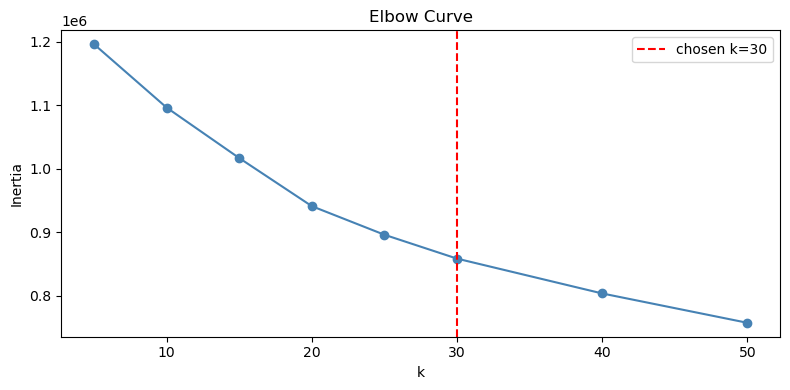

In [5]:
# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(features)

# Elbow curve — inertia vs k (optional, skip if slow)
run_elbow = True  # set False to skip
if run_elbow:
    ks = [5, 10, 15, 20, 25, 30, 40, 50]
    inertias = []
    for k in ks:
        km = MiniBatchKMeans(n_clusters=k, random_state=SEED, n_init=3, batch_size=4096)
        km.fit(X)
        inertias.append(km.inertia_)
        print(f'  k={k:>3}  inertia={km.inertia_:.0f}')
    plt.figure(figsize=(8, 4))
    plt.plot(ks, inertias, 'o-', color='steelblue')
    plt.axvline(K, color='red', linestyle='--', label=f'chosen k={K}')
    plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Curve'); plt.legend()
    plt.tight_layout(); plt.show()

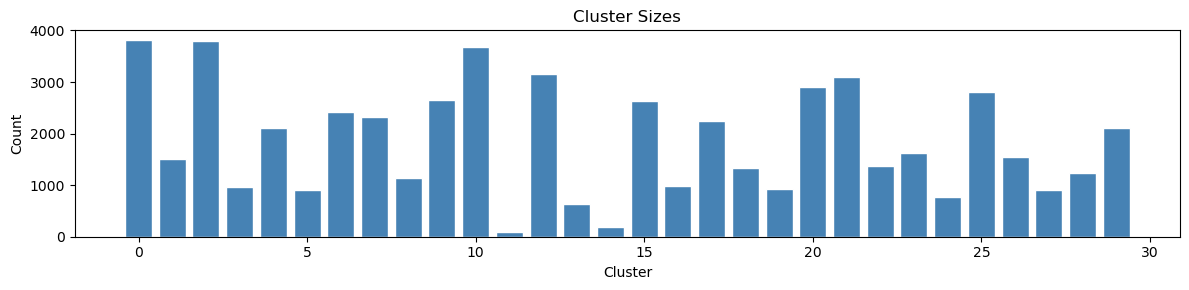

Smallest: 100  Largest: 3812  Mean: 1862


In [6]:
# Fit final model
if len(X) > 50_000:
    km = MiniBatchKMeans(n_clusters=K, random_state=SEED, n_init=5, batch_size=4096, max_iter=300)
else:
    km = KMeans(n_clusters=K, random_state=SEED, n_init=10, max_iter=300)

labels = km.fit_predict(X)
centroids_norm = km.cluster_centers_
centroids_orig = scaler.inverse_transform(centroids_norm)

meta['cluster'] = labels
np.save(os.path.join(OUT_DIR, 'centroids.npy'), centroids_orig.astype(np.float32))
np.save(os.path.join(OUT_DIR, 'labels.npy'), labels)

# Cluster sizes
sizes = pd.Series(labels).value_counts().sort_index()
plt.figure(figsize=(12,3))
plt.bar(sizes.index, sizes.values, color='steelblue', edgecolor='white')
plt.xlabel('Cluster'); plt.ylabel('Count'); plt.title('Cluster Sizes')
plt.tight_layout(); plt.show()
print(f'Smallest: {sizes.min()}  Largest: {sizes.max()}  Mean: {sizes.mean():.0f}')

## 4. Cluster Characterization

In [7]:
# Feature names for readability
feat_names = [
    'ball_px','ball_py','ball_pz','ball_vx','ball_vy','ball_vz',
    'own0_px','own0_py','own0_pz','own0_vx','own0_vy',
    'own1_px','own1_py','own1_pz','own1_vx','own1_vy',
    'own2_px','own2_py','own2_pz','own2_vx','own2_vy',
    'opp_cx','opp_cy','opp_cvx','opp_cvy',
    'opp_closest_dist','opp_med_dx','opp_med_dy'
]

centroids_df = pd.DataFrame(centroids_orig, columns=feat_names)
centroids_df['cluster'] = np.arange(K)
centroids_df['size'] = sizes.values

# Summarize by ball_py quintile (field position)
centroids_df['field_zone'] = pd.cut(centroids_df['ball_py'],
    bins=[-5200, -3000, -1000, 1000, 3000, 5200],
    labels=['deep_blue','mid_blue','center','mid_orange','deep_orange'])

print('Clusters per field zone:')
print(centroids_df.groupby('field_zone', observed=True)['cluster'].count())
print()
print('Centroid summary (ball_py, own0_py = deepest defender, opp_cy = opp centroid):')
centroids_df[['cluster','size','field_zone','ball_py','own0_py','own1_py','opp_cy']].sort_values('ball_py').to_string(index=False)

Clusters per field zone:
field_zone
mid_blue        2
center         26
mid_orange      1
deep_orange     1
Name: cluster, dtype: int64

Centroid summary (ball_py, own0_py = deepest defender, opp_cy = opp centroid):


' cluster  size  field_zone      ball_py      own0_py      own1_py       opp_cy\n      29  2100    mid_blue -1658.592163 -4454.213379 -3613.531250  -870.609253\n      24   764    mid_blue -1049.120850  -159.412354  2905.122559  3260.867188\n      27   904      center  -999.025208 -3578.284912 -1239.606323  3513.375977\n      19   920      center  -754.970093 -3036.529053   685.391479  3413.003418\n      16   992      center  -515.402100 -3815.736328 -1952.960449  3631.805176\n       3   968      center  -477.526520 -3664.429199 -1580.950928  3580.853516\n       8  1139      center  -298.094666 -3225.318604   150.261856  3463.654053\n       1  1500      center  -268.140717 -5120.953125 -3648.794189  3498.905762\n      17  2253      center  -147.352570 -4498.690430 -3856.693115  3323.558350\n      14   183      center   -98.241524 -3424.689941 -1959.682495  1387.573730\n       2  3805      center   -81.480286 -4265.534668 -3461.543945  3628.809082\n      10  3682      center   -71.856339

In [8]:
# Per-cluster metadata: scoring rate, perspective split, dominant profiles
cluster_meta = meta.groupby('cluster').agg(
    size=('match_id','count'),
    n_matches=('match_id','nunique'),
    pct_blue=('perspective', lambda x: (x=='blue').mean()),
    ball_py_mean=('ball_py','mean'),
    ball_py_std=('ball_py','std'),
    pct_scored=('blue_score', lambda x: ((meta.loc[x.index,'blue_score'] + meta.loc[x.index,'orange_score']) > 0).mean()),
).reset_index()
cluster_meta = cluster_meta.sort_values('ball_py_mean').reset_index(drop=True)
print(cluster_meta.to_string(index=False))

 cluster  size  n_matches  pct_blue  ball_py_mean  ball_py_std  pct_scored
      13   643         10  0.073095  -3641.847502  2271.038025    0.087092
      11   100          6  0.520000   -686.041734  2083.654025    0.470000
      29  2100         14  0.706667   -485.851325  2513.018424    0.230476
      14   183         13  0.480874   -207.120761  3179.843412    0.306011
      23  1623         20  0.452249    -79.512109  1246.570230    0.051756
      17  2253         26  0.541056    -51.134695   958.504603    0.071016
       7  2330         26  0.521030    -22.570342   782.951909    0.077253
      10  3682         30  0.352526    -19.995796   698.641907    0.041825
      15  2640         30  0.492424    -19.661668   998.035058    0.085985
      20  2899         30  0.282511    -13.114398   610.064877    0.047258
       2  3805         30  0.382392    -10.523954   690.703885    0.041524
      16   992         14  0.289315    -10.051634  2399.378492    0.259073
       9  2645         28

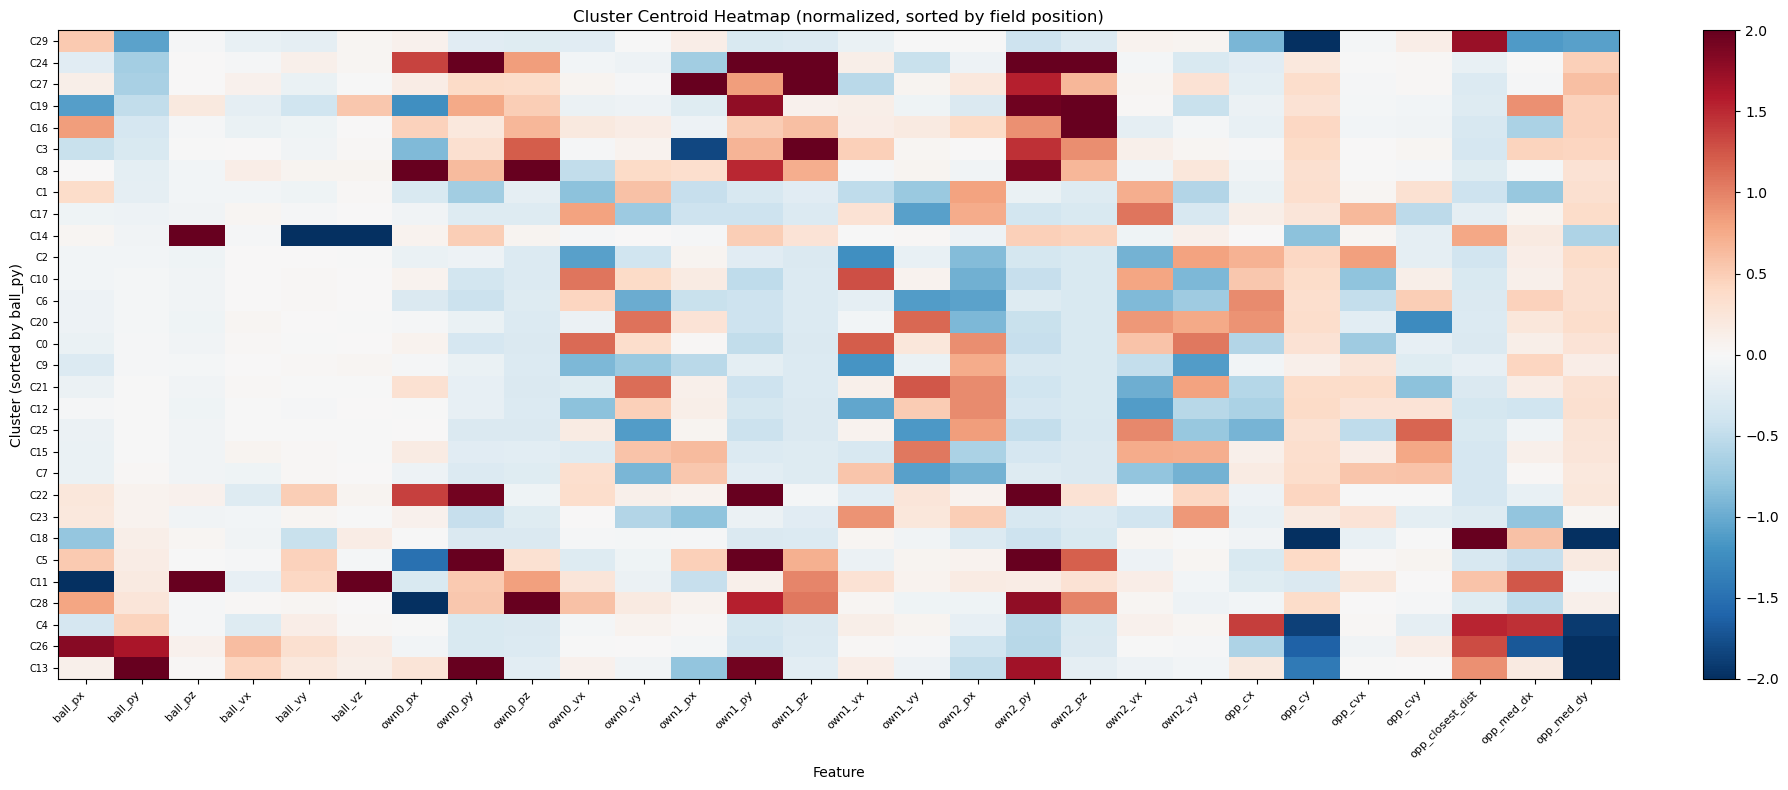

In [9]:
# Heatmap: centroid feature values (normalized)
fig, ax = plt.subplots(figsize=(18, 8))
sorted_order = centroids_df.sort_values('ball_py')['cluster'].values
data = centroids_norm[sorted_order]
im = ax.imshow(data, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
ax.set_xticks(range(len(feat_names))); ax.set_xticklabels(feat_names, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(K)); ax.set_yticklabels([f'C{c}' for c in sorted_order], fontsize=7)
ax.set_xlabel('Feature'); ax.set_ylabel('Cluster (sorted by ball_py)')
ax.set_title('Cluster Centroid Heatmap (normalized, sorted by field position)')
plt.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout(); plt.show()

## 5. Dimensionality Reduction Visualization

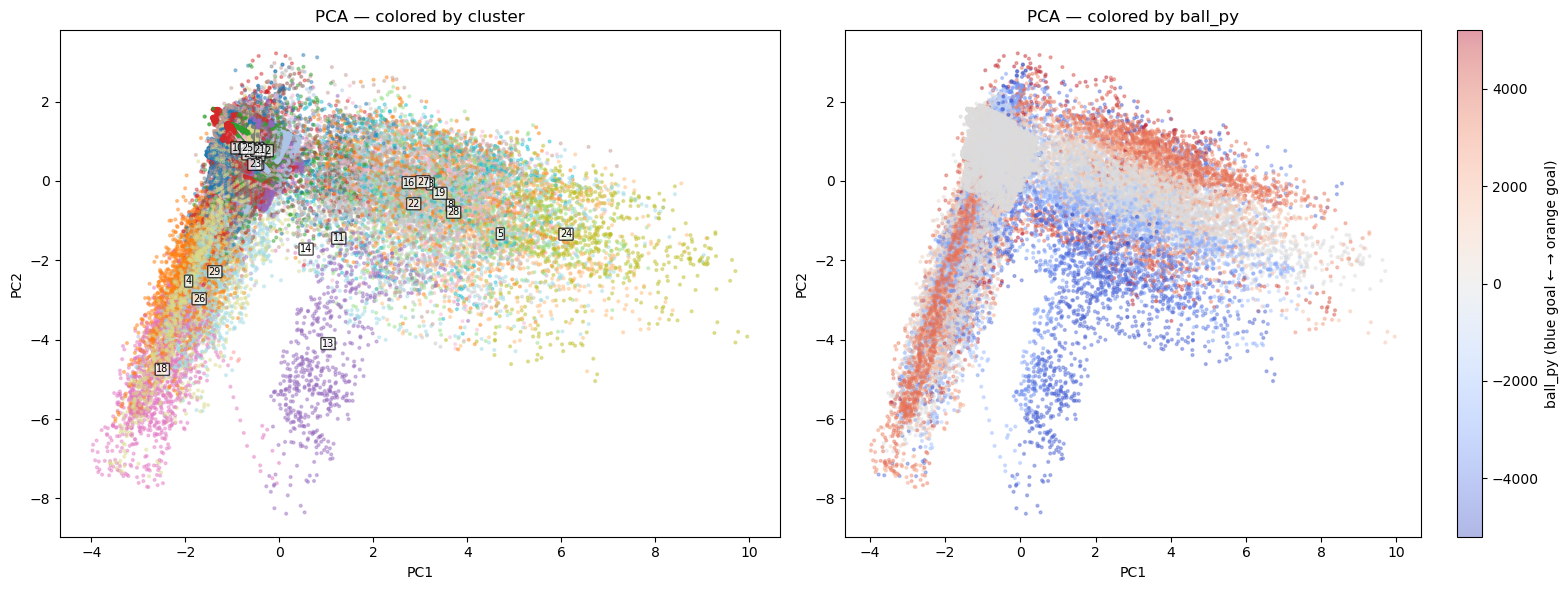

PCA variance explained: PC1=12.3%  PC2=8.9%


In [10]:
# PCA — fast overview
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X)
meta['pca0'] = X_pca[:,0]; meta['pca1'] = X_pca[:,1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color by cluster
sc = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab20', s=4, alpha=0.4)
# Annotate centroids
ctr_pca = pca.transform(centroids_norm)
for i, (cx, cy) in enumerate(ctr_pca):
    axes[0].text(cx, cy, str(i), fontsize=7, ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.7))
axes[0].set_title('PCA — colored by cluster'); axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# Color by ball_py (field position)
sc2 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=meta['ball_py'], cmap='coolwarm', s=4, alpha=0.4,
                      vmin=-5200, vmax=5200)
plt.colorbar(sc2, ax=axes[1], label='ball_py (blue goal ← → orange goal)')
axes[1].set_title('PCA — colored by ball_py'); axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout(); plt.show()
print(f'PCA variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

t-SNE on subsample of 8000


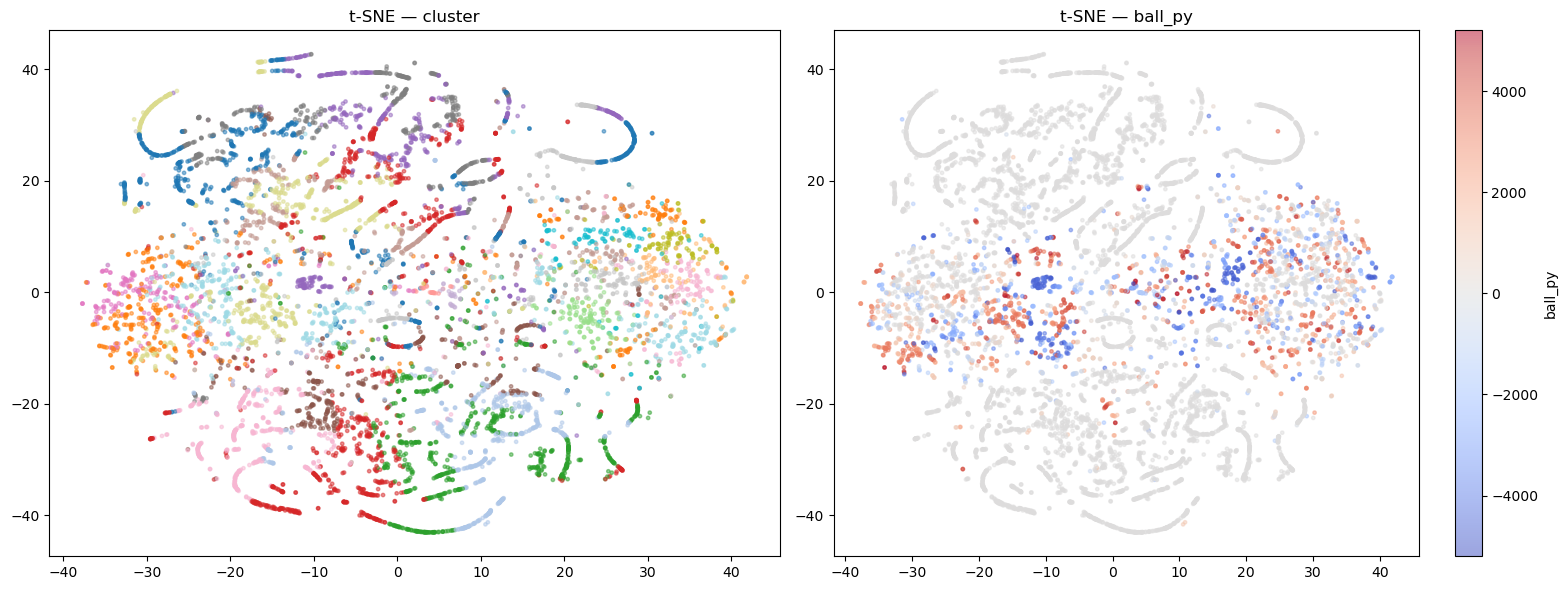

In [11]:
# t-SNE — richer structure (slower, subsample if needed)
MAX_TSNE = 8000
if len(X) > MAX_TSNE:
    idx = np.random.choice(len(X), MAX_TSNE, replace=False)
    X_sub, labels_sub, meta_sub = X[idx], labels[idx], meta.iloc[idx].reset_index(drop=True)
    print(f't-SNE on subsample of {MAX_TSNE}')
else:
    X_sub, labels_sub, meta_sub = X, labels, meta

tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, n_iter=500)
X_tsne = tsne.fit_transform(X_sub)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(X_tsne[:,0], X_tsne[:,1], c=labels_sub, cmap='tab20', s=6, alpha=0.5)
axes[0].set_title('t-SNE — cluster')
sc3 = axes[1].scatter(X_tsne[:,0], X_tsne[:,1], c=meta_sub['ball_py'], cmap='coolwarm', s=6, alpha=0.5,
                      vmin=-5200, vmax=5200)
plt.colorbar(sc3, ax=axes[1], label='ball_py')
axes[1].set_title('t-SNE — ball_py')
plt.tight_layout(); plt.show()

## 6. Field Position Visualization — Cluster Formations

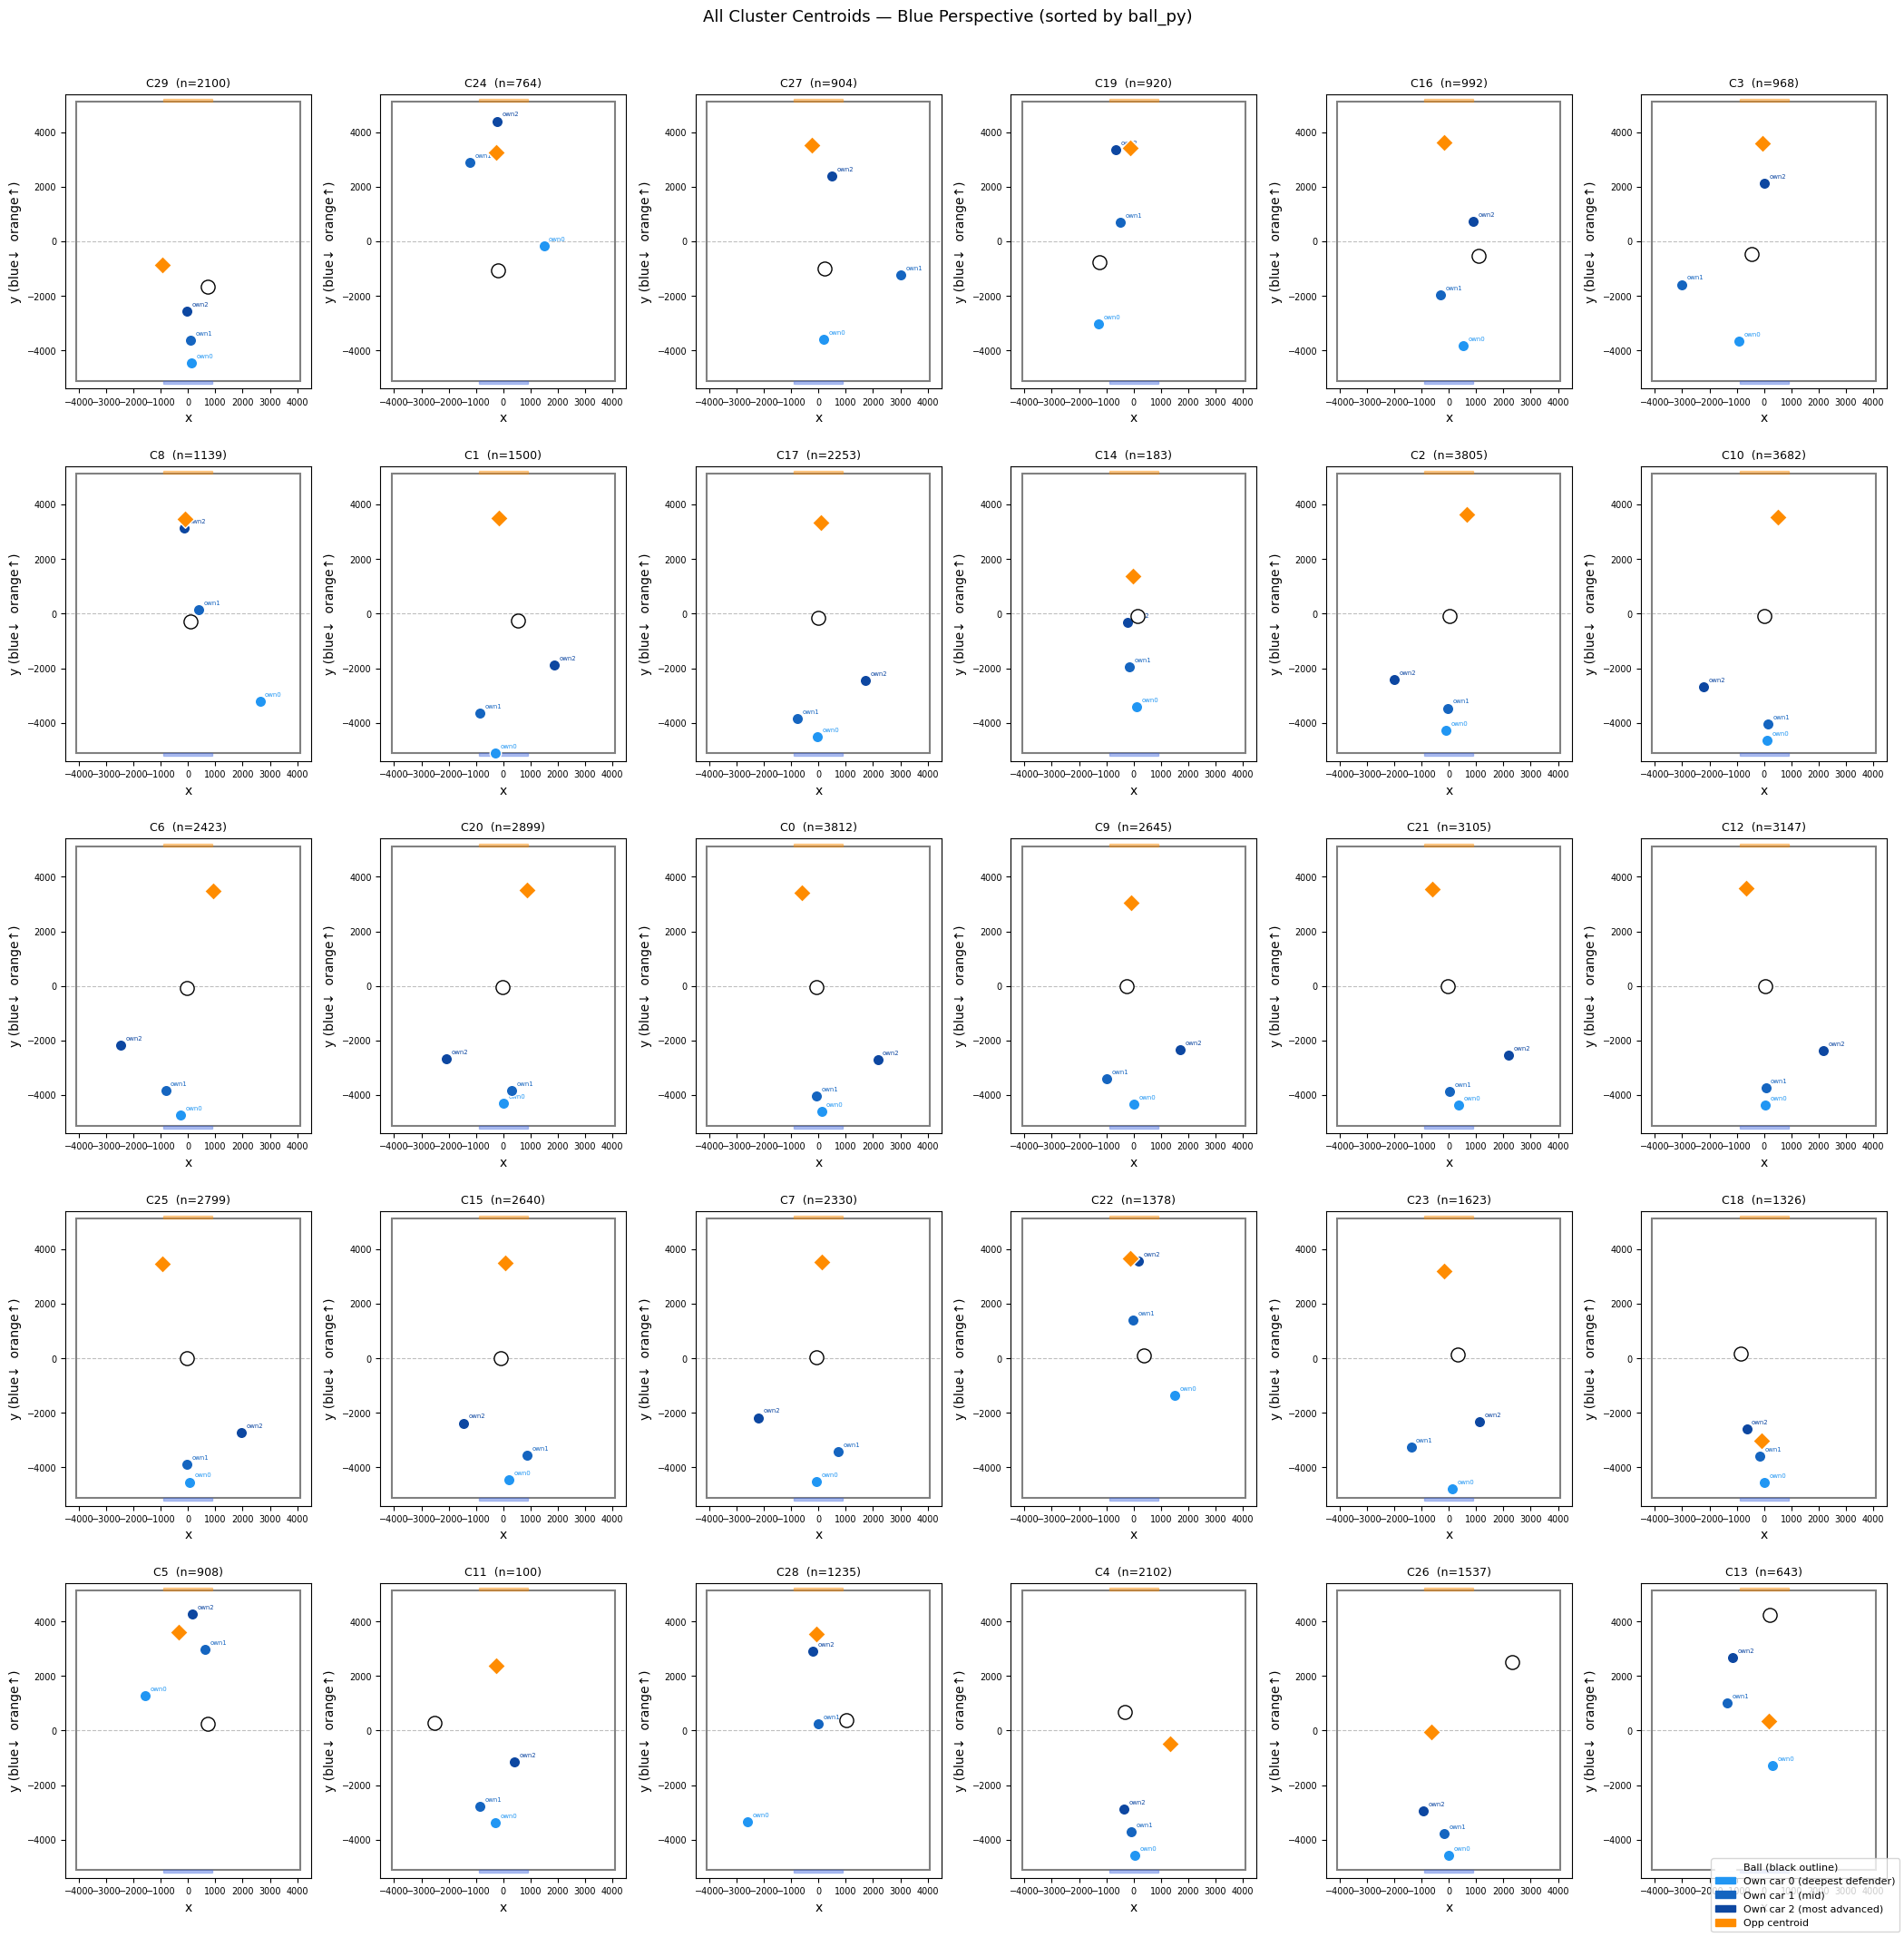

Saved: c:\Users\nick2\Desktop\School Stuff\stats\AI-Portfolio\RL\out\formation_clusters\cluster_formations.png


In [12]:
def draw_field(ax, title=''):
    """Draw a top-down Rocket League field outline."""
    from matplotlib.patches import FancyArrowPatch
    # Field bounds: ±4096 x, ±5120 y
    field = plt.Rectangle((-4096, -5120), 8192, 10240, fill=False, edgecolor='gray', linewidth=1.5)
    ax.add_patch(field)
    # Goals
    blue_goal  = plt.Rectangle((-893, -5220), 1786, 100, color='royalblue', alpha=0.4)
    orange_goal= plt.Rectangle((-893,  5120), 1786, 100, color='darkorange', alpha=0.4)
    ax.add_patch(blue_goal); ax.add_patch(orange_goal)
    # Midfield line
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlim(-4500, 4500); ax.set_ylim(-5400, 5400)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=9)
    ax.set_xlabel('x'); ax.set_ylabel('y (blue↓  orange↑)')
    ax.tick_params(labelsize=7)

# Plot all cluster centroids in a grid (blue perspective)
COLS = 6
ROWS = (K + COLS - 1) // COLS
fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS*3.5, ROWS*4.2))
axes = axes.flatten()

sorted_clusters = centroids_df.sort_values('ball_py')['cluster'].values

for plot_idx, cid in enumerate(sorted_clusters):
    ax = axes[plot_idx]
    draw_field(ax, title=f'C{cid}  (n={sizes[cid]})')

    c = centroids_orig[cid]
    # Ball
    ax.scatter([c[0]], [c[1]], s=120, color='white', edgecolors='black', zorder=5, marker='o')
    # Own cars (blue perspective: own=blue, sorted defender→attacker)
    own_colors = ['#2196F3','#1565C0','#0D47A1']  # light→dark blue
    for i in range(3):
        px, py = c[6+i*5], c[6+i*5+1]
        ax.scatter([px], [py], s=80, color=own_colors[i], edgecolors='white', zorder=4)
        ax.annotate(f'own{i}', (px, py), textcoords='offset points', xytext=(4,4), fontsize=5, color=own_colors[i])
    # Opponent centroid
    ax.scatter([c[21]], [c[22]], s=100, color='darkorange', edgecolors='white', zorder=4, marker='D')

# Hide unused axes
for ax in axes[K:]:
    ax.set_visible(False)

# Legend
legend_els = [
    mpatches.Patch(color='white', label='Ball (black outline)'),
    mpatches.Patch(color='#2196F3', label='Own car 0 (deepest defender)'),
    mpatches.Patch(color='#1565C0', label='Own car 1 (mid)'),
    mpatches.Patch(color='#0D47A1', label='Own car 2 (most advanced)'),
    mpatches.Patch(color='darkorange', label='Opp centroid'),
]
fig.legend(handles=legend_els, loc='lower right', fontsize=8)
fig.suptitle('All Cluster Centroids — Blue Perspective (sorted by ball_py)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'cluster_formations.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved: {os.path.join(OUT_DIR, 'cluster_formations.png')}")

## 7. Temporal Sequence Analysis — Do Clusters Chain?

Same-cluster consecutive rate: 57.0% (31,817/55,800)
Unique transitions observed: 601


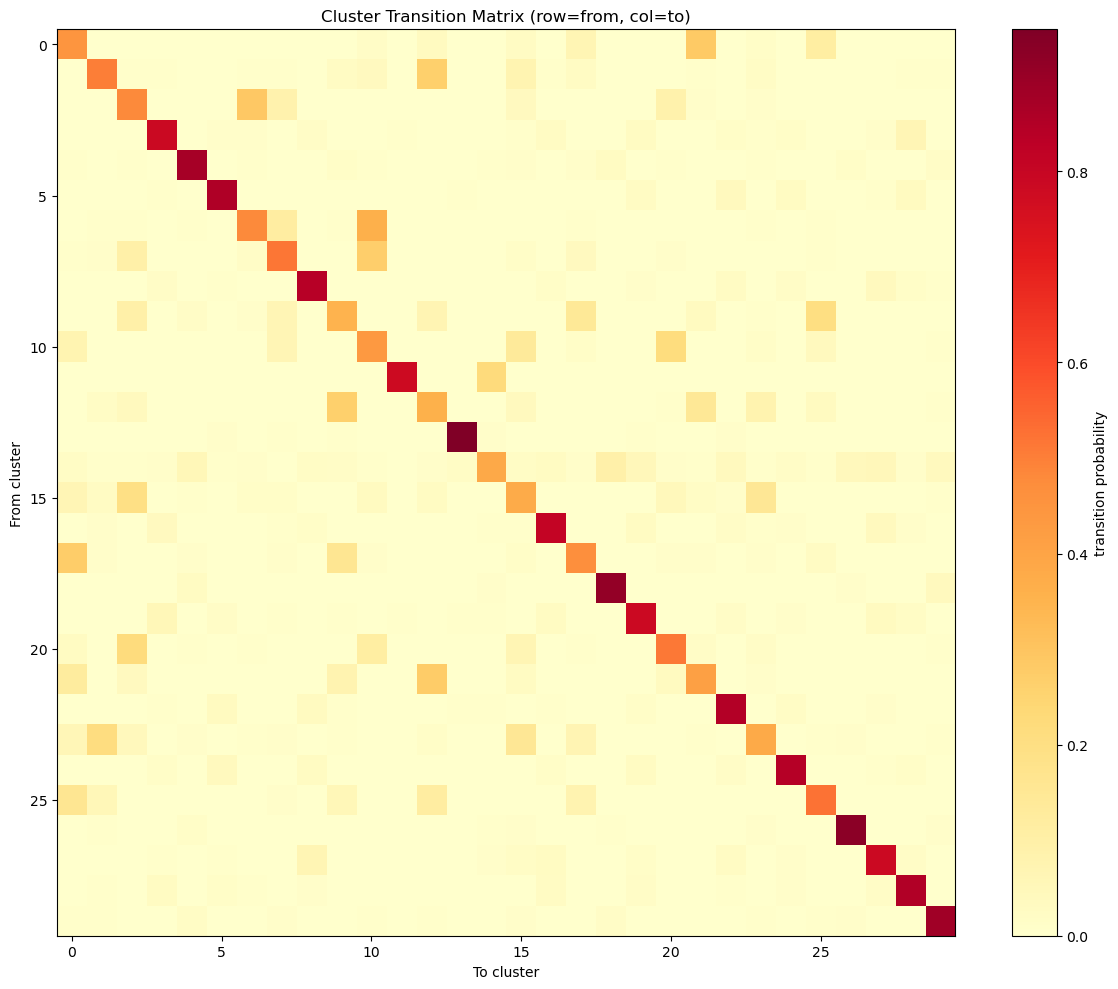

In [13]:
# For each match, look at the cluster sequence over time (both perspectives)
# High autocorrelation means consecutive ticks stay in the same cluster

from collections import Counter

transitions = Counter()  # (from_cluster, to_cluster)
same_count, total_count = 0, 0

for (mid, persp), grp in meta.sort_values('tick').groupby(['match_id','perspective']):
    seq = grp['cluster'].values
    for a, b in zip(seq[:-1], seq[1:]):
        transitions[(a, b)] += 1
        total_count += 1
        if a == b:
            same_count += 1

print(f'Same-cluster consecutive rate: {same_count/total_count*100:.1f}% ({same_count:,}/{total_count:,})')
print(f'Unique transitions observed: {len(transitions)}')

# Transition matrix heatmap
T = np.zeros((K, K))
for (a, b), cnt in transitions.items():
    T[a, b] = cnt
T_norm = T / (T.sum(axis=1, keepdims=True) + 1e-9)  # row-normalize

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(T_norm, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='transition probability')
ax.set_title('Cluster Transition Matrix (row=from, col=to)')
ax.set_xlabel('To cluster'); ax.set_ylabel('From cluster')
plt.tight_layout(); plt.show()

## 8. Profile Behavior Per Cluster

In [14]:
# Attach profile info from raw data (sampled at same ticks as features)
# Sample the raw data at the same rows we used for features
profile_records = []
for f in csv_files:
    rows = pd.read_csv(f)
    for i in range(0, len(rows), SUBSAMPLE):
        row = rows.iloc[i]
        for persp, slots in [('blue', ['blue-0','blue-1','blue-2']),
                              ('orange', ['orange-0','orange-1','orange-2'])]:
            profiles = [str(row.get(f'{s}_profile','')) for s in slots]
            profile_records.append({
                'match_id': int(row['match_id']), 'tick': int(row['tick']),
                'perspective': persp,
                'car0_profile': profiles[0], 'car1_profile': profiles[1], 'car2_profile': profiles[2],
            })

profile_df = pd.DataFrame(profile_records)
# Merge on match_id + tick + perspective
merged = meta.merge(profile_df, on=['match_id','tick','perspective'], how='left')

# For each cluster: most common profile per car slot
print('Most common profiles per cluster (car slot 0 = deepest defender):')
print(f'{"Cluster":>8} {"size":>6} {"ball_py":>8} {"car0":>10} {"car1":>10} {"car2":>10}')
for cid in centroids_df.sort_values('ball_py')['cluster'].values:
    sub = merged[merged.cluster == cid]
    p0 = sub.car0_profile.mode()[0] if len(sub) else '-'
    p1 = sub.car1_profile.mode()[0] if len(sub) else '-'
    p2 = sub.car2_profile.mode()[0] if len(sub) else '-'
    bpy = centroids_orig[cid][1]
    print(f'{cid:>8} {sizes[cid]:>6} {bpy:>8.0f} {p0:>10} {p1:>10} {p2:>10}')

Most common profiles per cluster (car slot 0 = deepest defender):
 Cluster   size  ball_py       car0       car1       car2
      29   2100    -1659         s0         s0         s0
      24    764    -1049         p1         p1         p1
      27    904     -999         p1         p1         p1
      19    920     -755         p1         p1         p1
      16    992     -515         p1         p1         p1
       3    968     -478         p1         p1         p1
       8   1139     -298         p1         p1         p1
       1   1500     -268         s2         s2         s2
      17   2253     -147         s5         s5         s5
      14    183      -98         p1         p1         p1
       2   3805      -81         s0         s0         s0
      10   3682      -72         s0         s0         s0
       6   2423      -62         d3         d3         d3
      20   2899      -51         s0         s0         s0
       0   3812      -43         s0         s0         s0
      

In [15]:
# Profile entropy per cluster — how much variety does the HL show?
from scipy.stats import entropy

print(f'\n{"Cluster":>8} {"entropy_c0":>12} {"entropy_c1":>12} {"entropy_c2":>12}  (higher = more HL switching)')
for cid in range(K):
    sub = merged[merged.cluster == cid]
    def ent(col):
        vc = sub[col].value_counts(normalize=True)
        return entropy(vc.values, base=2)
    print(f'{cid:>8} {ent("car0_profile"):>12.3f} {ent("car1_profile"):>12.3f} {ent("car2_profile"):>12.3f}')


 Cluster   entropy_c0   entropy_c1   entropy_c2  (higher = more HL switching)
       0        2.299        2.299        2.299
       1        2.516        2.516        2.516
       2        2.173        2.173        2.173
       3        0.549        0.549        0.549
       4        2.268        2.268        2.268
       5        0.734        0.734        0.734
       6        2.366        2.366        2.366
       7        1.727        1.727        1.727
       8        0.835        0.835        0.835
       9        2.169        2.169        2.169
      10        2.232        2.232        2.232
      11        2.316        2.316        2.316
      12        2.505        2.505        2.505
      13        1.196        1.196        1.196
      14        2.485        2.485        2.485
      15        2.513        2.513        2.513
      16        0.964        0.964        0.964
      17        2.232        2.232        2.232
      18        2.355        2.355        2.355
      19 

## 9. Replay Candidate Summary

In [16]:
# Show which clusters are best replay candidates and their representative ticks
import json

cluster_info = []
for cid in range(K):
    mask = labels == cid
    idxs = np.where(mask)[0]
    # Representative: closest to centroid in normalized space
    dists = np.linalg.norm(X[idxs] - centroids_norm[cid], axis=1)
    rep_idx = idxs[int(np.argmin(dists))]
    rep = meta.iloc[rep_idx]
    c = centroids_orig[cid]
    cluster_info.append({
        'cluster_id': int(cid),
        'size': int(mask.sum()),
        'field_zone': str(centroids_df.loc[centroids_df.cluster==cid,'field_zone'].values[0]),
        'ball_py': round(float(c[1]), 1),
        'ball_speed': round(float(np.sqrt(c[3]**2+c[4]**2+c[5]**2)), 1),
        'own_spread_y': round(float(max(c[7],c[12],c[17]) - min(c[7],c[12],c[17])), 1),
        'representative': {
            'match_id': int(rep.match_id), 'tick': int(rep.tick),
            'time_s': float(rep.time_s), 'perspective': str(rep.perspective),
            'source_file': str(rep.source_file),
        },
    })

cluster_info.sort(key=lambda x: x['ball_py'])
with open(os.path.join(OUT_DIR, 'cluster_info.json'), 'w') as fj:
    json.dump(cluster_info, fj, indent=2)
print(f'Saved cluster_info.json')

print(f'\n{"C":>3} {"size":>5} {"zone":>14} {"ball_py":>8} {"ball_spd":>9} {"own_spread":>11}  representative')
for c in cluster_info:
    r = c['representative']
    print(f'{c["cluster_id"]:>3} {c["size"]:>5} {c["field_zone"]:>14} {c["ball_py"]:>8.0f} '
          f'{c["ball_speed"]:>9.1f} {c["own_spread_y"]:>11.0f}  '
          f'm{r["match_id"]} t{r["tick"]} ({r["perspective"]}) {r["source_file"]}')

Saved cluster_info.json

  C  size           zone  ball_py  ball_spd  own_spread  representative
 29  2100       mid_blue    -1659      30.2        1897  m1022 t23064 (blue) 1022)team3_balancevteam2_striker_heavy.csv
 24   764       mid_blue    -1049      14.8        4563  m1022 t33544 (orange) 1022)team3_balancevteam2_striker_heavy.csv
 27   904         center     -999      20.5        5958  m1022 t3920 (orange) 1022)team3_balancevteam2_striker_heavy.csv
 19   920         center     -755      61.7        6380  m1026 t32632 (orange) 1026)team8_baselinevteam2_striker_heavy.csv
 16   992         center     -515      20.0        4555  m972 t3280 (orange) 972)team1_striker_balancevteam2_striker_heavy.csv
  3   968         center     -478      10.5        5796  m972 t2680 (orange) 972)team1_striker_balancevteam2_striker_heavy.csv
  8  1139         center     -298      18.1        6372  m1022 t11680 (orange) 1022)team3_balancevteam2_striker_heavy.csv
  1  1500         center     -268      13

## 10. Single Match Deep-Dive

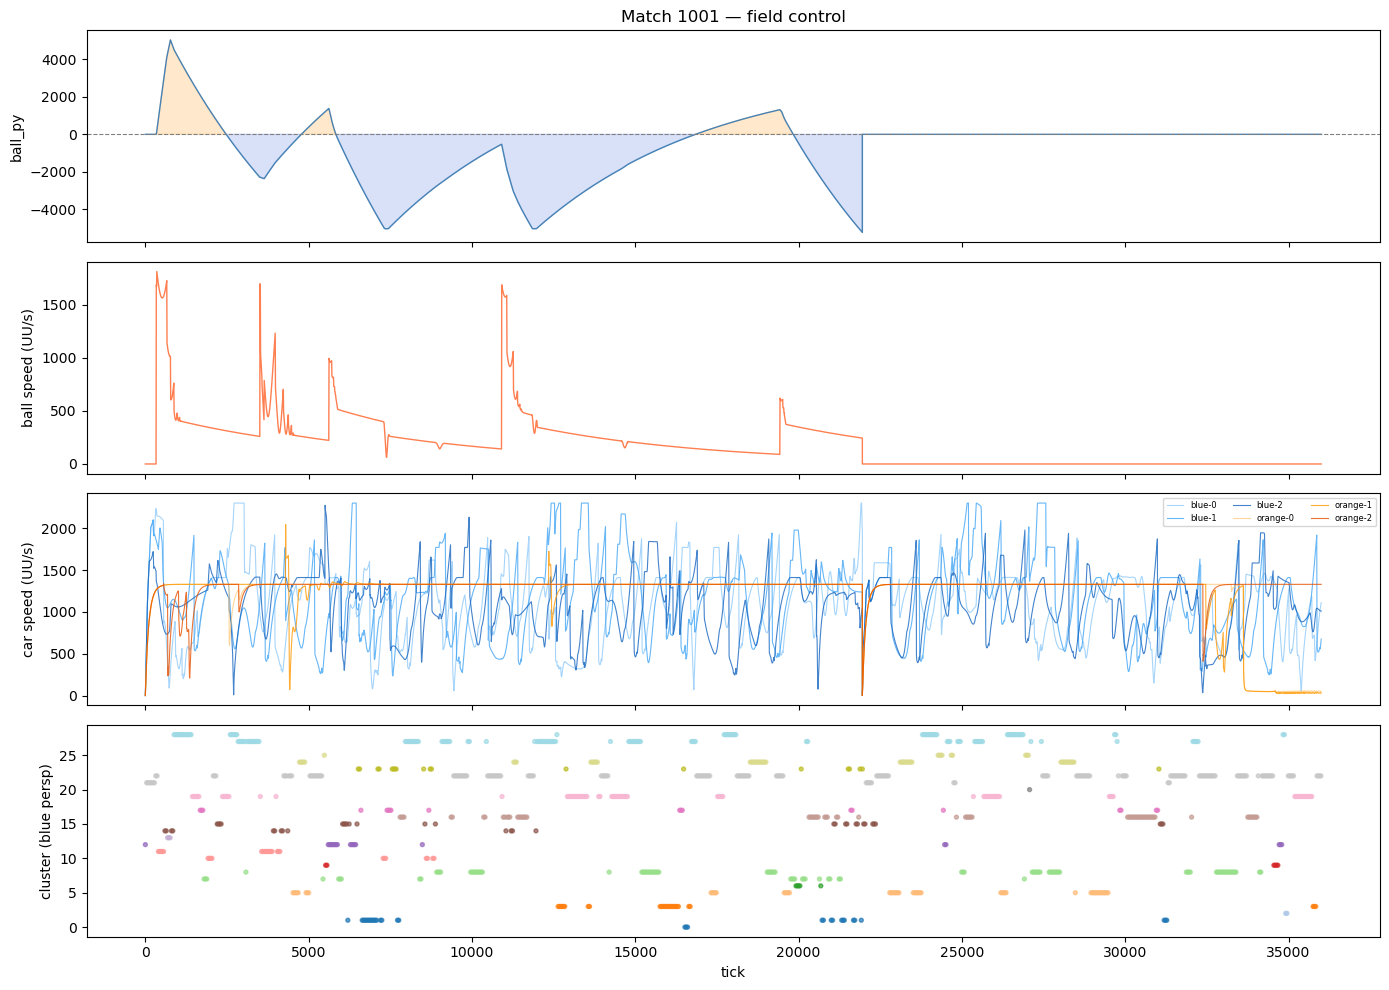

In [17]:
# Pick a specific match to visualize cluster assignment over time
# Change this to any match_id you want to inspect
INSPECT_MATCH = meta.match_id.iloc[0]  # default: first match

m = meta[meta.match_id == INSPECT_MATCH].sort_values('tick')
raw_m = raw[raw.match_id == INSPECT_MATCH].sort_values('tick')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# Ball py
axes[0].plot(raw_m.tick, raw_m.ball_py, color='steelblue', linewidth=1)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_ylabel('ball_py'); axes[0].set_title(f'Match {INSPECT_MATCH} — field control')
axes[0].fill_between(raw_m.tick, raw_m.ball_py, 0, where=raw_m.ball_py>0, alpha=0.2, color='darkorange')
axes[0].fill_between(raw_m.tick, raw_m.ball_py, 0, where=raw_m.ball_py<0, alpha=0.2, color='royalblue')

# Ball speed
bspd = np.sqrt(raw_m.ball_vx**2 + raw_m.ball_vy**2 + raw_m.ball_vz**2)
axes[1].plot(raw_m.tick, bspd, color='coral', linewidth=1)
axes[1].set_ylabel('ball speed (UU/s)')

# Car speeds
for slot, color in [('blue-0','#90CAF9'),('blue-1','#42A5F5'),('blue-2','#1565C0'),
                    ('orange-0','#FFCC80'),('orange-1','#FF9800'),('orange-2','#E65100')]:
    try:
        spd = np.sqrt(raw_m[f'{slot}_vx']**2 + raw_m[f'{slot}_vy']**2 + raw_m[f'{slot}_vz']**2)
        axes[2].plot(raw_m.tick, spd, color=color, linewidth=0.8, alpha=0.8, label=slot)
    except KeyError:
        pass
axes[2].set_ylabel('car speed (UU/s)'); axes[2].legend(fontsize=6, ncol=3)

# Cluster assignment (blue perspective)
mb = m[m.perspective=='blue'].sort_values('tick')
axes[3].scatter(mb.tick, mb.cluster, s=8, c=mb.cluster, cmap='tab20', alpha=0.7)
axes[3].set_ylabel('cluster (blue persp)'); axes[3].set_xlabel('tick')

plt.tight_layout(); plt.show()